# **Machine Learning Task: HR Attrition Prediction (Classification)**

## Problem Statement



Employee attrition is a critical issue for organizations, leading to increased hiring costs, productivity loss, and reduced employee morale.
In this project, the goal is to build a Machine Learning classification model that predicts whether an employee will leave the company (Attrition: Yes/No)based on features such as:
  - Age
  - Salary
  - Job Role
  - Job Satisfaction
  - Work Experience
  - Overtime
  - Work-Life Balance
  - Department
  
Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting employee attrition.

# Objective

The objective of this task is to:
- Understand and explore the HR dataset
- Perform data preprocessing (missing values, duplicates, outliers)
- Conduct Exploratory Data Analysis (EDA)
- Apply encoding and feature scaling
- Train multiple classification algorithms
- Evaluate models using classification metrics
- Perform cross-validation and hyperparameter tuning
- Select the best-performing model

# **Tasks**


1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Load the Dataset

In [ ]:
data = pd.read_csv('HR-Employee-Attrition.csv')

In [ ]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# Domain Analysis – HR Employee Attrition Dataset

Target Variable:
Attrition → Indicates whether an employee leaves the company (Yes / No).

1. Age
   - Represents the employee’s age. Younger employees may switch jobs frequently, while older employees may prefer stability.

2. Salary / Monthly Income
    - Indicates employee earnings. Lower salary may increase the probability of attrition.

3. Job Role
    - Specifies the employee’s designation (Manager, Developer, HR, etc.). Some roles may have higher stress levels leading to attrition.

4. Job Satisfaction

    - Measures how satisfied employees are with their work. Low satisfaction increases the chance of leaving.

5. Work Experience / Years at Company

    - Shows how long an employee has worked. Employees with less experience may leave for better opportunities.

6. Overtime

    - Indicates whether the employee works extra hours. Frequent overtime may cause burnout.

7. Work-Life Balance

    - Represents balance between job and personal life. Poor balance increases attrition risk.

8. Department

    - Shows department such as Sales, HR, IT. Some departments may have higher attrition due to workload.

9. Education

    - Represents qualification level. Highly educated employees may look for better opportunities.

10. Marital Status

    - Personal factor influencing job stability.

11. Environment Satisfaction

    - Represents employee satisfaction with workplace environment.

12. Performance Rating

    - Shows how well the employee performs in the company.

### **3. Basic Checks**

In [ ]:
# check number of rows and columns
data.shape

(1470, 35)

In [ ]:
# print first 5 rows
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# print last 5 rows
data.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [ ]:
# check info: memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# print all columns
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
# print numerical columns
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
# print only categorical columns
cat_cols= data.select_dtypes(include='object')
cat_cols

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [ ]:
# check data type of each column
data.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
# find statistical report for numerical data
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# find statistical report for categorical data
data.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [ ]:
# find unique values
for x in cat_cols:
  print(x,'-->',data[x].unique())

Attrition --> ['Yes' 'No']
BusinessTravel --> ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department --> ['Sales' 'Research & Development' 'Human Resources']
EducationField --> ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender --> ['Female' 'Male']
JobRole --> ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
MaritalStatus --> ['Single' 'Married' 'Divorced']
Over18 --> ['Y']
OverTime --> ['Yes' 'No']


### **Data Cleaning**

4. Check for missing values and handle them

In [ ]:
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


5. Check for duplicates and if any duplicate just drop

In [ ]:
data.duplicated().sum()

np.int64(0)

**6. Univariate analysis**

Analysing single variable / column
- histogram
- count plot
- box plot

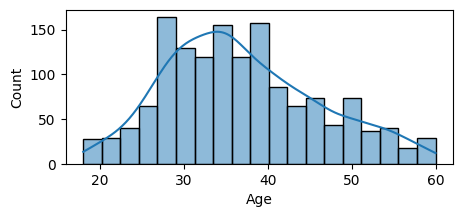

In [ ]:
# check the distribution of age
plt.figure(figsize=(5,2))
sns.histplot(data,x='Age',kde=True)
plt.show()

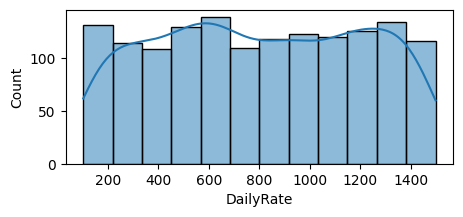

In [ ]:
# check the distribution of DailyRate
plt.figure(figsize=(5,2))
sns.histplot(data,x='DailyRate',kde=True)
plt.show()

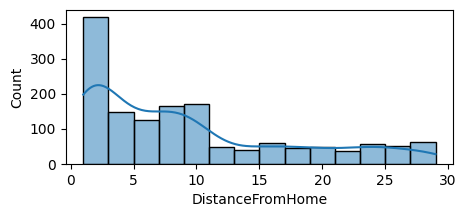

In [ ]:
# check the distribution of DistanceFromHome
plt.figure(figsize=(5,2))
sns.histplot(data,x='DistanceFromHome',kde=True)
plt.show()

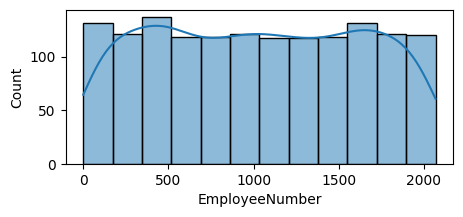

In [ ]:
# check the distribution of EmployeeNumber
plt.figure(figsize=(5,2))
sns.histplot(data,x='EmployeeNumber',kde=True)
plt.show()

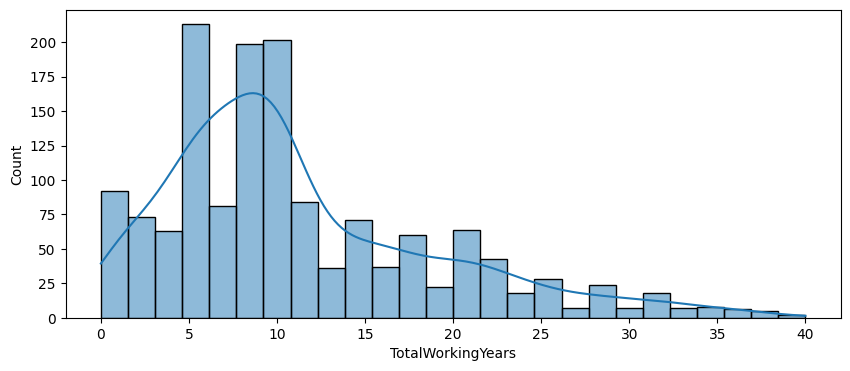

In [ ]:
# check the distribution of TotalWorkingYears
plt.figure(figsize=(10,4))
sns.histplot(data,x='TotalWorkingYears',kde=True)
plt.show()

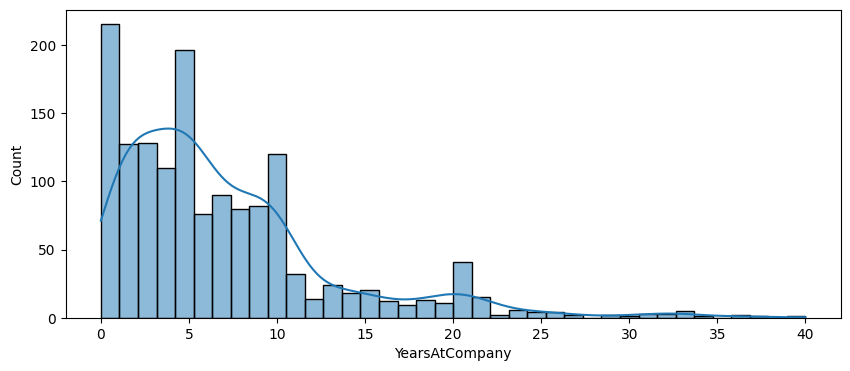

In [ ]:
# check the distribution of YearsAtCompany
plt.figure(figsize=(10,4))
sns.histplot(data,x='YearsAtCompany',kde=True)
plt.show()

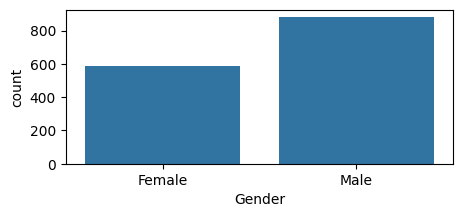

In [ ]:
# Visualise count of male and female
plt.figure(figsize=(5,2))
sns.countplot(data,x='Gender')
plt.show()

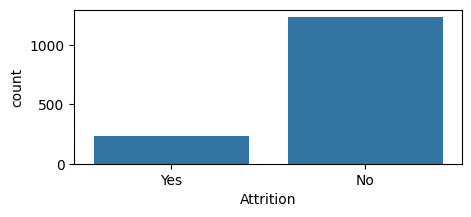

In [ ]:
# Visualise count of Attrition
plt.figure(figsize=(5,2))
sns.countplot(data,x='Attrition')
plt.show()

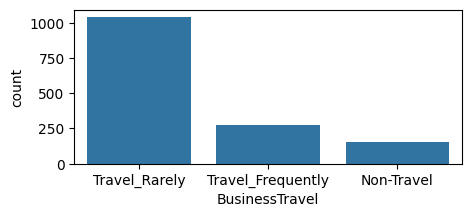

In [ ]:
# Visualise count of BusinessTravel
plt.figure(figsize=(5,2))
sns.countplot(data,x='BusinessTravel')
plt.show()

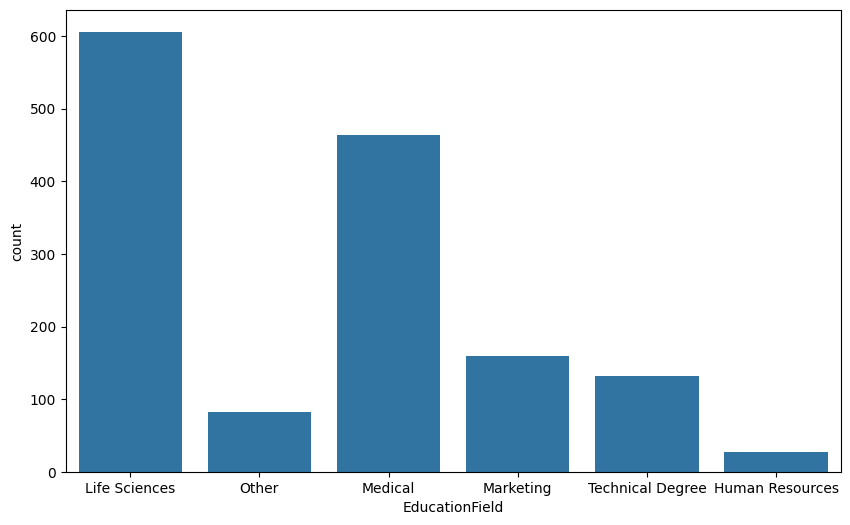

In [ ]:
# Visualise count of EducationField
plt.figure(figsize=(10,6))
sns.countplot(data,x='EducationField')
plt.show()

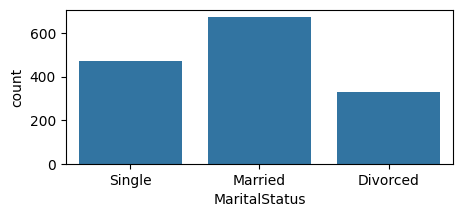

In [ ]:
# Visualise count of MaritalStatus
plt.figure(figsize=(5,2))
sns.countplot(data,x='MaritalStatus')
plt.show()

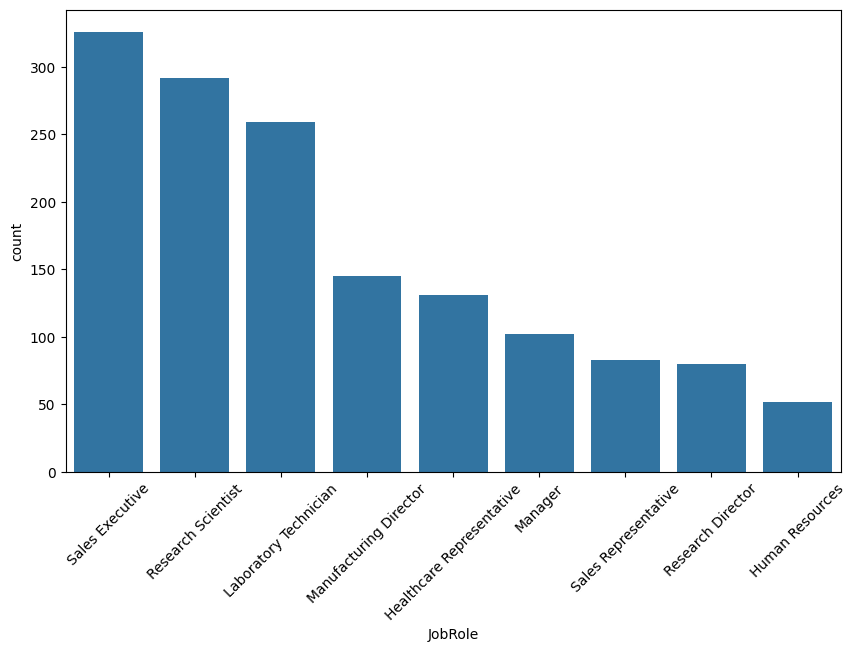

In [ ]:
# Visualise count of JobRole
plt.figure(figsize=(10,6))
sns.countplot(data,x='JobRole')
plt.xticks(rotation=45) # to rotalte the names in diagonal way
plt.show()

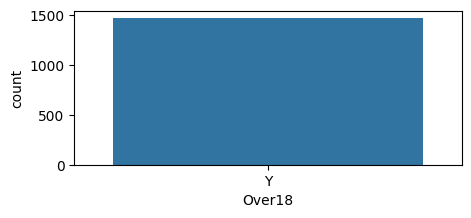

In [ ]:
# Visualise count of Over18
plt.figure(figsize=(5,2))
sns.countplot(data,x='Over18')
plt.show()

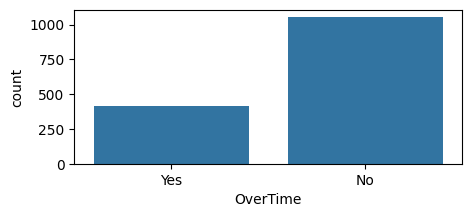

In [ ]:
# Visualise count of OverTime
plt.figure(figsize=(5,2))
sns.countplot(data,x='OverTime')
plt.show()

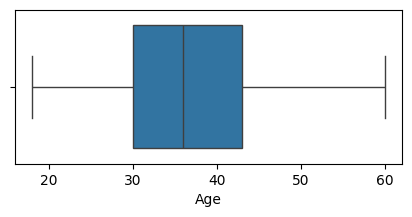

In [ ]:
# check outliers in age
plt.figure(figsize=(5,2))
sns.boxplot(data,x='Age')
plt.show()

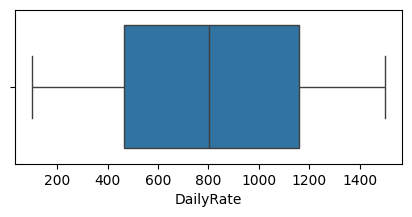

In [ ]:
# check outliers in DailyRate
plt.figure(figsize=(5,2))
sns.boxplot(data,x='DailyRate')
plt.show()

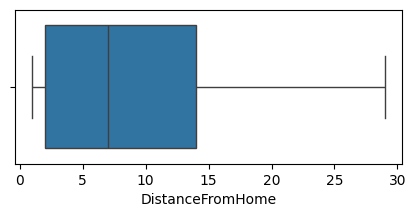

In [ ]:
# check outliers in DistanceFromHome
plt.figure(figsize=(5,2))
sns.boxplot(data,x='DistanceFromHome')
plt.show()

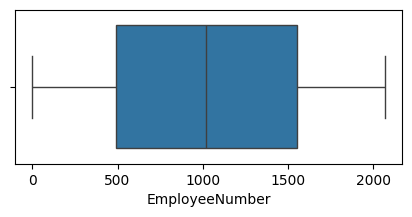

In [ ]:
# check outliers in EmployeeNumber
plt.figure(figsize=(5,2))
sns.boxplot(data,x='EmployeeNumber')
plt.show()

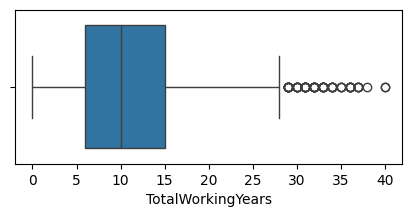

In [ ]:
# check outliers in TotalWorkingYears
plt.figure(figsize=(5,2))
sns.boxplot(data,x='TotalWorkingYears')
plt.show()

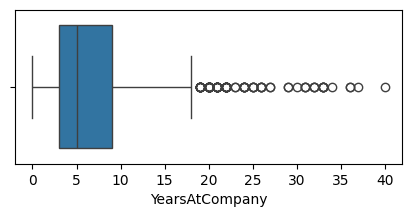

In [ ]:
# check outliers in YearsAtCompany
plt.figure(figsize=(5,2))
sns.boxplot(data,x='YearsAtCompany')
plt.show()

**7. Bivariate Analysis**
Analysing two variables/columns
* Scatter
* line
* bar plot

now for categorical columns

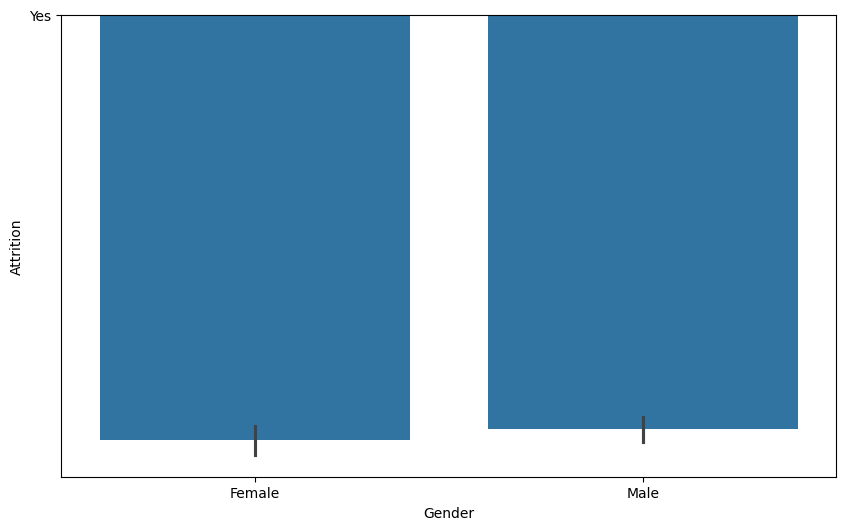

In [ ]:
# Compare how charges vary with gender
plt.figure(figsize=(10,6))
sns.barplot(data,x='Gender',y='Attrition')
plt.show()

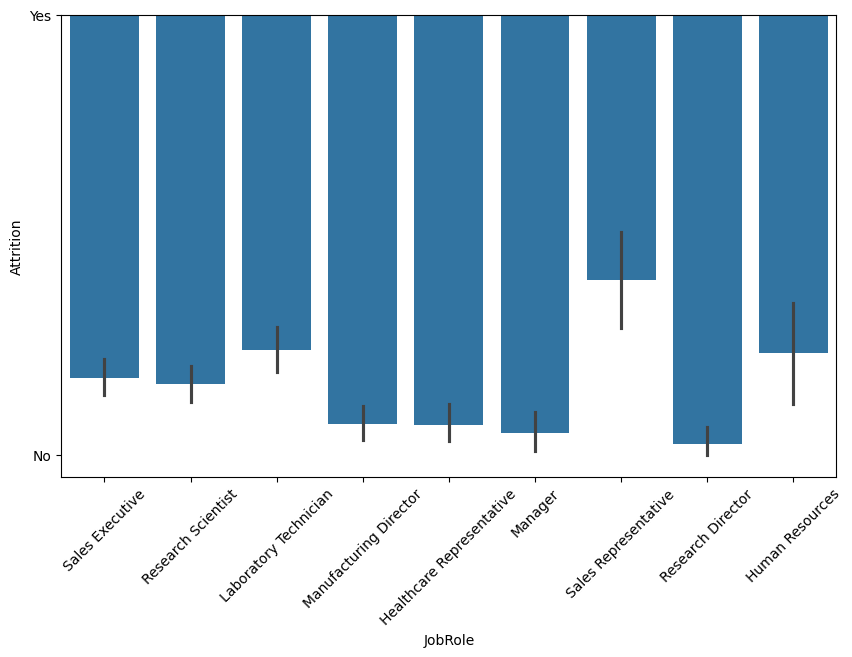

In [ ]:
# Compare how charges vary with JobRole
plt.figure(figsize=(10,6))
sns.barplot(data,x='JobRole',y='Attrition')
plt.xticks(rotation=45) # to rotalte the names in diagonal way
plt.show()

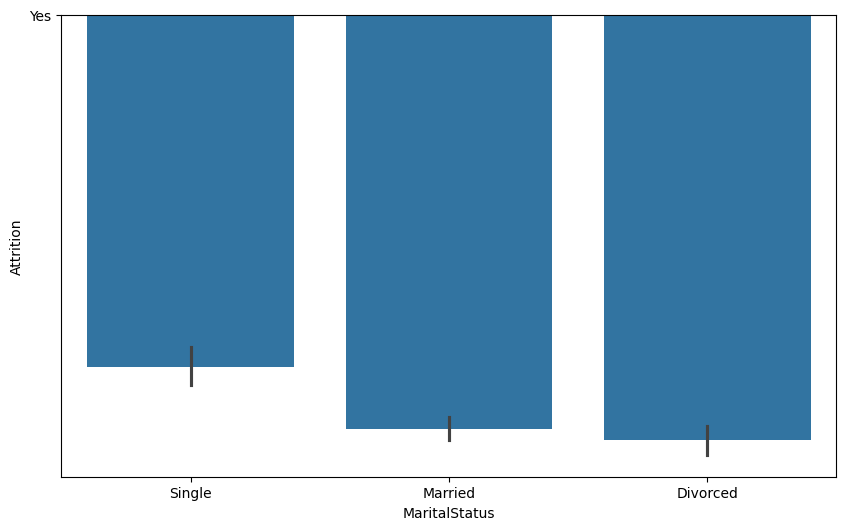

In [ ]:
# Compare how charges vary with MaritalStatus
plt.figure(figsize=(10,6))
sns.barplot(data,x='MaritalStatus',y='Attrition')
plt.show()

we r not doing for over18 because everyone r over18 years


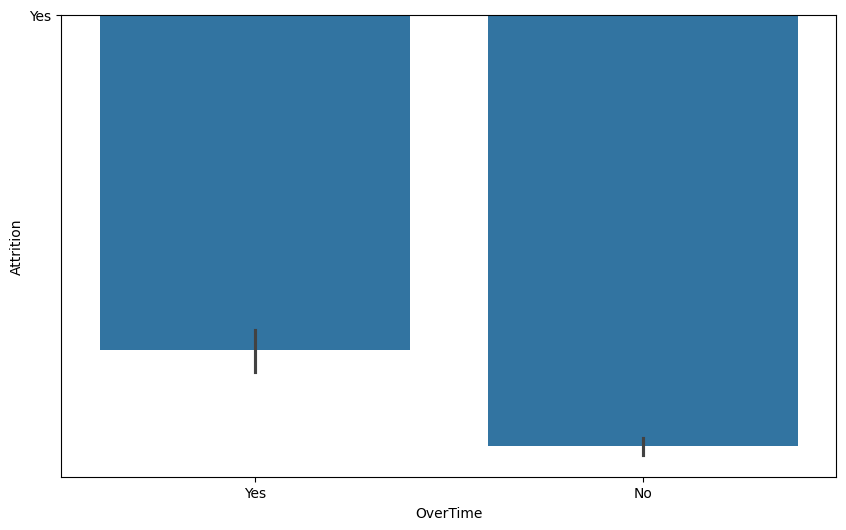

In [ ]:
# Compare how charges vary with OverTime
plt.figure(figsize=(10,6))
sns.barplot(data,x='OverTime',y='Attrition')
plt.show()

now for numerical columns

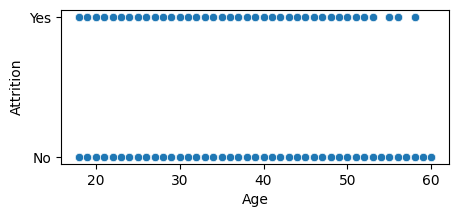

In [ ]:
# check the relationship between Age and Attrition
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Age',y='Attrition')
plt.show()

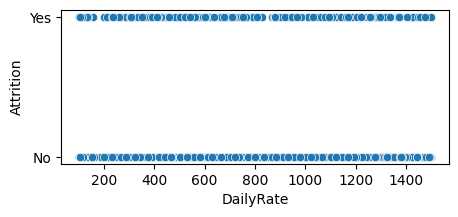

In [ ]:
# check the relationship between DailyRate and Attrition
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='DailyRate',y='Attrition')
plt.show()

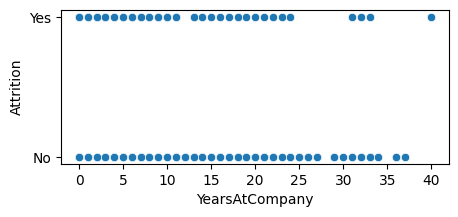

In [ ]:
# check the relationship between YearsAtCompany and Attrition
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='YearsAtCompany',y='Attrition')
plt.show()

In [ ]:
# pairplot: It creates scatter plot among all the numerical variables
# sns.pairplot(data)


# heat map : Used to visualise the correlation
# Correlation measures how strong two variables



In [ ]:
num_cols.corr()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


<Axes: >

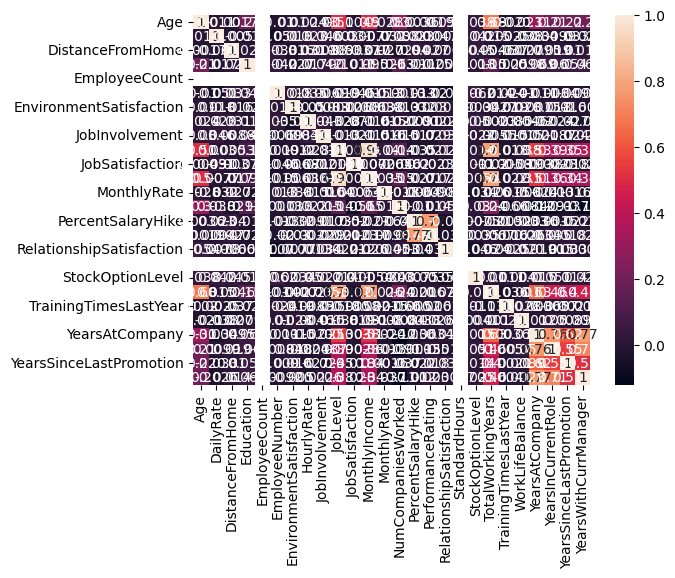

In [ ]:
sns.heatmap(num_cols.corr(),annot=True)

**9.Handle Outliers**

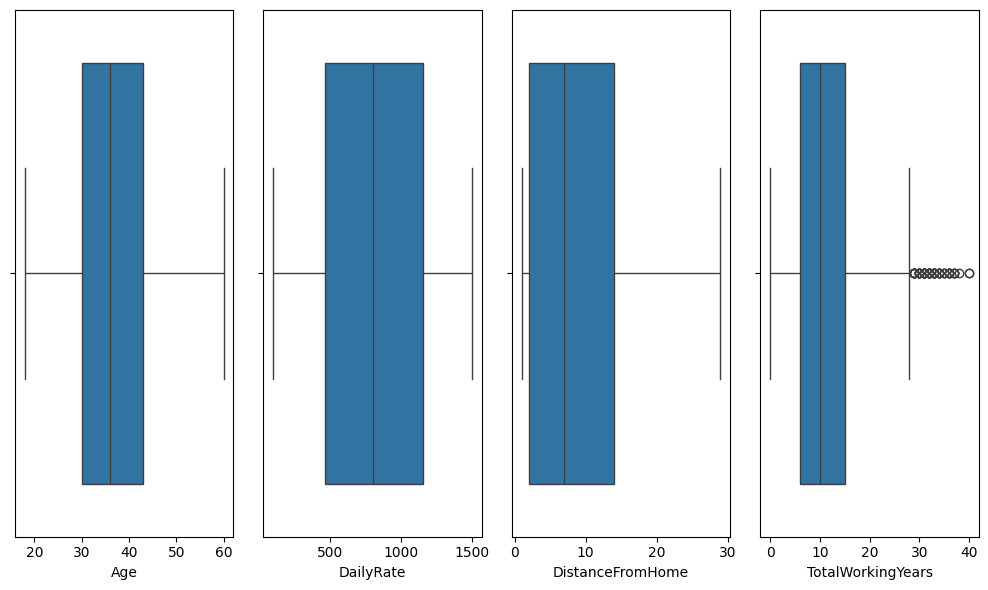

In [ ]:
fig,ax = plt.subplots(1,4,figsize=(10,6))
sns.boxplot(data,x='Age',ax=ax[0])
sns.boxplot(data,x='DailyRate',ax=ax[1])
sns.boxplot(data,x='DistanceFromHome',ax=ax[2])
sns.boxplot(data,x='TotalWorkingYears',ax=ax[3])


plt.tight_layout()

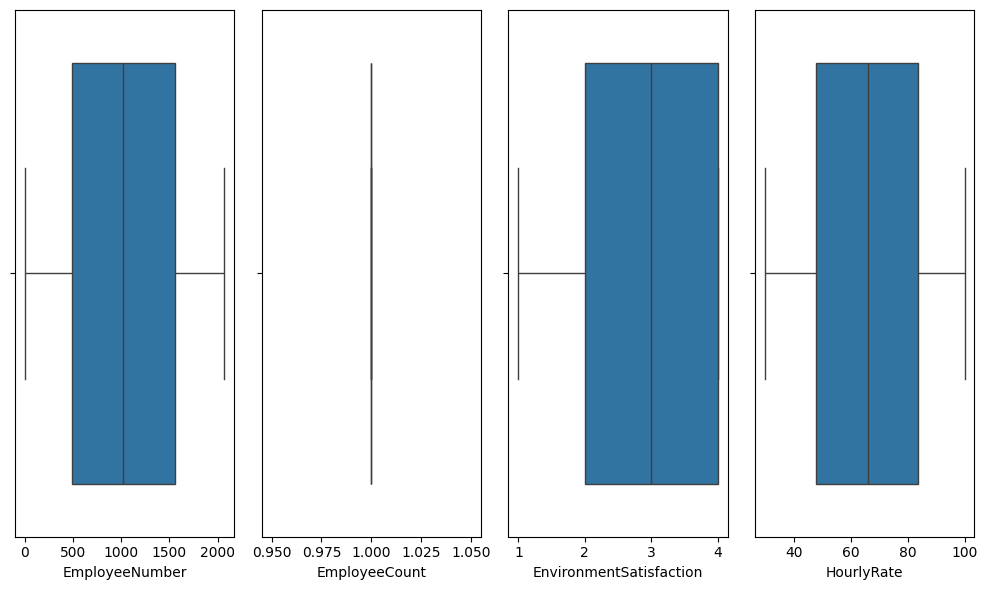

In [ ]:
fig,ax = plt.subplots(1,4,figsize=(10,6))
sns.boxplot(data,x='EmployeeNumber',ax=ax[0])
sns.boxplot(data,x='EmployeeCount',ax=ax[1])
sns.boxplot(data,x='EnvironmentSatisfaction',ax=ax[2])
sns.boxplot(data,x='HourlyRate',ax=ax[3])
plt.tight_layout()

In [ ]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Find Outliers**
1. IQR(Inter quartile range): Used when data distribution is skewed.
2. 3-sigma rule : Used when data is normal
3. Outliers should handled only if % of outliers are less than 5%.

**Check the distibution of Age and YearsAtCompany**

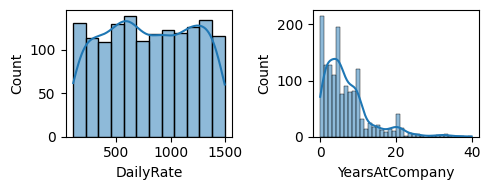

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(5,2))
sns.histplot(data,x='DailyRate',ax=ax[0],kde=True)
sns.histplot(data,x='YearsAtCompany',ax=ax[1],kde=True)
plt.tight_layout()

In [ ]:
# find skew
data.loc[:,'DailyRate'].skew()

np.float64(-0.003518568352325854)

In [ ]:
# find skew
data.loc[:,'YearsAtCompany'].skew()

np.float64(1.7645294543422085)

- DailyRate data distribution is normal.
- YearsAtCompany distribution is right skewed.

**IQR method for Charges**

Data distribution is skewed

1. Find Q1
2. FInd Q3
3. IQR
4. lower_limit = Q1-1.5*IQR
5. upper_limit = Q3+ 1.5*IQR
6. If any value greater than upper limit or less than lower limit , we call them as outliers.

In [ ]:
Q1 = data.loc[:,'YearsAtCompany'].quantile(0.25)
Q3 = data.loc[:,'YearsAtCompany'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter all the values greater than upper_limit
data[data.loc[:,'YearsAtCompany']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
18,53,No,Travel_Rarely,1219,Sales,2,4,Life Sciences,1,23,...,3,80,0,31,3,3,25,8,3,7
28,44,No,Travel_Rarely,477,Research & Development,7,4,Medical,1,36,...,4,80,1,24,4,3,22,6,5,17
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,15,15,8
62,50,No,Travel_Rarely,989,Research & Development,7,2,Medical,1,80,...,4,80,1,29,2,2,27,3,13,8
63,59,No,Travel_Rarely,1435,Sales,25,3,Life Sciences,1,81,...,4,80,0,28,3,2,21,16,7,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,39,No,Travel_Rarely,119,Sales,15,4,Marketing,1,1975,...,1,80,0,21,3,3,20,8,11,10
1404,42,No,Non-Travel,335,Research & Development,23,2,Life Sciences,1,1976,...,4,80,0,20,2,3,20,9,3,7
1443,42,No,Travel_Rarely,300,Research & Development,2,3,Life Sciences,1,2031,...,1,80,0,24,2,2,22,6,4,14
1445,41,No,Travel_Rarely,582,Research & Development,28,4,Life Sciences,1,2034,...,3,80,1,21,3,3,20,7,0,10


In [ ]:
# filter values less than lower_limit
data[data.loc[:,'YearsAtCompany']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# percentage of outliers
len(data[(data.loc[:,'YearsAtCompany']>upper_limit)|(data.loc[:,'YearsAtCompany']<lower_limit)
])/len(data)*100

7.07482993197279

Since % of outliers are 7.07% which are more than 5% that means all these high YearAtCompany are important. If age is high obviously insurance charge will be high.

**3 Sigma rule for DailyRate**

Data distribution of DailyRate is normal

1. Find mean
2. Find Standard deviation
3. lower limit = mean - 3* std
4. upper limit = mean + 3* std
5. Any value greater than upper limit or less than lower limit is considered as outlier.

In [ ]:
mean_val= data.loc[:,'DailyRate'].mean()
std_val =data.loc[:,'DailyRate'].std()
lower_limit = mean_val - 3*std_val
upper_limit = mean_val + 3*std_val

In [ ]:
# filter values greater than upper limit
data[data.loc[:,'DailyRate']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# filter values less than lower limit
data[data.loc[:,'DailyRate']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
# find %
len(data[(data.loc[:,'DailyRate']>upper_limit)|(data.loc[:,'DailyRate']<lower_limit)])/len(data)*100

0.0

since % of outliers is less than 5% we need to replace them with mean.

In [ ]:
data.loc[data.loc[:,'DailyRate']>upper_limit,'DailyRate']= data.loc[:,'DailyRate'].mean()

/tmp/ipykernel_965/2294661473.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '802.4857142857143' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data.loc[:,'DailyRate']>upper_limit,'DailyRate']= data.loc[:,'DailyRate'].mean()


In [ ]:
data[data.loc[:,'DailyRate']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


## **Encoding Techniques**

The process of converting text to numerical so that machine can can understand.

* Label Encoder
* One hot Encoder

# **Label Encoder**
Label Encoder assigns unique numbers to text starting from 0 according to alphabetical order.

label encoding for Attrition

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'attrition']= le.fit_transform(data.loc[:,'Attrition'])

In [ ]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,attrition
0,41,Yes,Travel_Rarely,1102.0,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279.0,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373.0,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392.0,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591.0,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884.0,Research & Development,23,2,Medical,1,2061,...,80,1,17,3,3,5,2,0,3,0
1466,39,No,Travel_Rarely,613.0,Research & Development,6,1,Medical,1,2062,...,80,1,9,5,3,7,7,1,7,0
1467,27,No,Travel_Rarely,155.0,Research & Development,4,3,Life Sciences,1,2064,...,80,1,6,0,3,6,2,0,3,0
1468,49,No,Travel_Frequently,1023.0,Sales,2,3,Medical,1,2065,...,80,0,17,3,2,9,6,0,8,0


In [ ]:
# drop old Attrition column
data.drop(columns='Attrition',inplace=True)


In [ ]:
data

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,attrition
0,41,Travel_Rarely,1102.0,Sales,1,2,Life Sciences,1,1,2,...,80,0,8,0,1,6,4,0,5,1
1,49,Travel_Frequently,279.0,Research & Development,8,1,Life Sciences,1,2,3,...,80,1,10,3,3,10,7,1,7,0
2,37,Travel_Rarely,1373.0,Research & Development,2,2,Other,1,4,4,...,80,0,7,3,3,0,0,0,0,1
3,33,Travel_Frequently,1392.0,Research & Development,3,4,Life Sciences,1,5,4,...,80,0,8,3,3,8,7,3,0,0
4,27,Travel_Rarely,591.0,Research & Development,2,1,Medical,1,7,1,...,80,1,6,3,3,2,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Travel_Frequently,884.0,Research & Development,23,2,Medical,1,2061,3,...,80,1,17,3,3,5,2,0,3,0
1466,39,Travel_Rarely,613.0,Research & Development,6,1,Medical,1,2062,4,...,80,1,9,5,3,7,7,1,7,0
1467,27,Travel_Rarely,155.0,Research & Development,4,3,Life Sciences,1,2064,2,...,80,1,6,0,3,6,2,0,3,0
1468,49,Travel_Frequently,1023.0,Sales,2,3,Medical,1,2065,4,...,80,0,17,3,2,9,6,0,8,0


# One hot Encoding
Creates new columns according to categories and assign 1 if value exists else 0.

In [ ]:
# gender
data=pd.get_dummies(data,columns=['Gender'],dtype='int')
data

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,attrition,Gender_Female,Gender_Male
0,41,Travel_Rarely,1102.0,Sales,1,2,Life Sciences,1,1,2,...,8,0,1,6,4,0,5,1,1,0
1,49,Travel_Frequently,279.0,Research & Development,8,1,Life Sciences,1,2,3,...,10,3,3,10,7,1,7,0,0,1
2,37,Travel_Rarely,1373.0,Research & Development,2,2,Other,1,4,4,...,7,3,3,0,0,0,0,1,0,1
3,33,Travel_Frequently,1392.0,Research & Development,3,4,Life Sciences,1,5,4,...,8,3,3,8,7,3,0,0,1,0
4,27,Travel_Rarely,591.0,Research & Development,2,1,Medical,1,7,1,...,6,3,3,2,2,2,2,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Travel_Frequently,884.0,Research & Development,23,2,Medical,1,2061,3,...,17,3,3,5,2,0,3,0,0,1
1466,39,Travel_Rarely,613.0,Research & Development,6,1,Medical,1,2062,4,...,9,5,3,7,7,1,7,0,0,1
1467,27,Travel_Rarely,155.0,Research & Development,4,3,Life Sciences,1,2064,2,...,6,0,3,6,2,0,3,0,0,1
1468,49,Travel_Frequently,1023.0,Sales,2,3,Medical,1,2065,4,...,17,3,2,9,6,0,8,0,0,1


In [ ]:
# EducationField
data=pd.get_dummies(data,columns=['EducationField'],dtype='int')
data

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,...,YearsWithCurrManager,attrition,Gender_Female,Gender_Male,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,41,Travel_Rarely,1102.0,Sales,1,2,1,1,2,94,...,5,1,1,0,0,1,0,0,0,0
1,49,Travel_Frequently,279.0,Research & Development,8,1,1,2,3,61,...,7,0,0,1,0,1,0,0,0,0
2,37,Travel_Rarely,1373.0,Research & Development,2,2,1,4,4,92,...,0,1,0,1,0,0,0,0,1,0
3,33,Travel_Frequently,1392.0,Research & Development,3,4,1,5,4,56,...,0,0,1,0,0,1,0,0,0,0
4,27,Travel_Rarely,591.0,Research & Development,2,1,1,7,1,40,...,2,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Travel_Frequently,884.0,Research & Development,23,2,1,2061,3,41,...,3,0,0,1,0,0,0,1,0,0
1466,39,Travel_Rarely,613.0,Research & Development,6,1,1,2062,4,42,...,7,0,0,1,0,0,0,1,0,0
1467,27,Travel_Rarely,155.0,Research & Development,4,3,1,2064,2,87,...,3,0,0,1,0,1,0,0,0,0
1468,49,Travel_Frequently,1023.0,Sales,2,3,1,2065,4,63,...,8,0,0,1,0,0,0,1,0,0


In [ ]:
# Department
data=pd.get_dummies(data,columns=['Department'],dtype='int')
data

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,Gender_Male,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Department_Human Resources,Department_Research & Development,Department_Sales
0,41,Travel_Rarely,1102.0,1,2,1,1,2,94,3,...,0,0,1,0,0,0,0,0,0,1
1,49,Travel_Frequently,279.0,8,1,1,2,3,61,2,...,1,0,1,0,0,0,0,0,1,0
2,37,Travel_Rarely,1373.0,2,2,1,4,4,92,2,...,1,0,0,0,0,1,0,0,1,0
3,33,Travel_Frequently,1392.0,3,4,1,5,4,56,3,...,0,0,1,0,0,0,0,0,1,0
4,27,Travel_Rarely,591.0,2,1,1,7,1,40,3,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Travel_Frequently,884.0,23,2,1,2061,3,41,4,...,1,0,0,0,1,0,0,0,1,0
1466,39,Travel_Rarely,613.0,6,1,1,2062,4,42,2,...,1,0,0,0,1,0,0,0,1,0
1467,27,Travel_Rarely,155.0,4,3,1,2064,2,87,4,...,1,0,1,0,0,0,0,0,1,0
1468,49,Travel_Frequently,1023.0,2,3,1,2065,4,63,2,...,1,0,0,0,1,0,0,0,0,1


In [ ]:
# BusinessTravel
data=pd.get_dummies(data,columns=['BusinessTravel'],dtype='int')
data

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Department_Human Resources,Department_Research & Development,Department_Sales,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely
0,41,1102.0,1,2,1,1,2,94,3,2,...,0,0,0,0,0,0,1,0,0,1
1,49,279.0,8,1,1,2,3,61,2,2,...,0,0,0,0,0,1,0,0,1,0
2,37,1373.0,2,2,1,4,4,92,2,1,...,0,0,1,0,0,1,0,0,0,1
3,33,1392.0,3,4,1,5,4,56,3,1,...,0,0,0,0,0,1,0,0,1,0
4,27,591.0,2,1,1,7,1,40,3,1,...,0,1,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884.0,23,2,1,2061,3,41,4,2,...,0,1,0,0,0,1,0,0,1,0
1466,39,613.0,6,1,1,2062,4,42,2,3,...,0,1,0,0,0,1,0,0,0,1
1467,27,155.0,4,3,1,2064,2,87,4,2,...,0,0,0,0,0,1,0,0,0,1
1468,49,1023.0,2,3,1,2065,4,63,2,2,...,0,1,0,0,0,0,1,0,1,0


In [ ]:
# JobRole
data=pd.get_dummies(data,columns=['JobRole'],dtype='int')
data

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,BusinessTravel_Travel_Rarely,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative
0,41,1102.0,1,2,1,1,2,94,3,2,...,1,0,0,0,0,0,0,0,1,0
1,49,279.0,8,1,1,2,3,61,2,2,...,0,0,0,0,0,0,0,1,0,0
2,37,1373.0,2,2,1,4,4,92,2,1,...,1,0,0,1,0,0,0,0,0,0
3,33,1392.0,3,4,1,5,4,56,3,1,...,0,0,0,0,0,0,0,1,0,0
4,27,591.0,2,1,1,7,1,40,3,1,...,1,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884.0,23,2,1,2061,3,41,4,2,...,0,0,0,1,0,0,0,0,0,0
1466,39,613.0,6,1,1,2062,4,42,2,3,...,1,1,0,0,0,0,0,0,0,0
1467,27,155.0,4,3,1,2064,2,87,4,2,...,1,0,0,0,0,1,0,0,0,0
1468,49,1023.0,2,3,1,2065,4,63,2,2,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
# MaritalStatus
data=pd.get_dummies(data,columns=['MaritalStatus'],dtype='int')
data

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1102.0,1,2,1,1,2,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,49,279.0,8,1,1,2,3,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,37,1373.0,2,2,1,4,4,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,33,1392.0,3,4,1,5,4,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,27,591.0,2,1,1,7,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884.0,23,2,1,2061,3,41,4,2,...,1,0,0,0,0,0,0,0,1,0
1466,39,613.0,6,1,1,2062,4,42,2,3,...,0,0,0,0,0,0,0,0,1,0
1467,27,155.0,4,3,1,2064,2,87,4,2,...,0,0,1,0,0,0,0,0,1,0
1468,49,1023.0,2,3,1,2065,4,63,2,2,...,0,0,0,0,0,1,0,0,1,0


In [ ]:
# Over18
data=pd.get_dummies(data,columns=['Over18'],dtype='int')
data

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y
0,41,1102.0,1,2,1,1,2,94,3,2,...,0,0,0,0,1,0,0,0,1,1
1,49,279.0,8,1,1,2,3,61,2,2,...,0,0,0,1,0,0,0,1,0,1
2,37,1373.0,2,2,1,4,4,92,2,1,...,0,0,0,0,0,0,0,0,1,1
3,33,1392.0,3,4,1,5,4,56,3,1,...,0,0,0,1,0,0,0,1,0,1
4,27,591.0,2,1,1,7,1,40,3,1,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884.0,23,2,1,2061,3,41,4,2,...,0,0,0,0,0,0,0,1,0,1
1466,39,613.0,6,1,1,2062,4,42,2,3,...,0,0,0,0,0,0,0,1,0,1
1467,27,155.0,4,3,1,2064,2,87,4,2,...,0,1,0,0,0,0,0,1,0,1
1468,49,1023.0,2,3,1,2065,4,63,2,2,...,0,0,0,0,1,0,0,1,0,1


In [ ]:
# OverTime
data=pd.get_dummies(data,columns=['OverTime'],dtype='int')
data

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,41,1102.0,1,2,1,1,2,94,3,2,...,0,0,1,0,0,0,1,1,0,1
1,49,279.0,8,1,1,2,3,61,2,2,...,0,1,0,0,0,1,0,1,1,0
2,37,1373.0,2,2,1,4,4,92,2,1,...,0,0,0,0,0,0,1,1,0,1
3,33,1392.0,3,4,1,5,4,56,3,1,...,0,1,0,0,0,1,0,1,0,1
4,27,591.0,2,1,1,7,1,40,3,1,...,0,0,0,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884.0,23,2,1,2061,3,41,4,2,...,0,0,0,0,0,1,0,1,1,0
1466,39,613.0,6,1,1,2062,4,42,2,3,...,0,0,0,0,0,1,0,1,1,0
1467,27,155.0,4,3,1,2064,2,87,4,2,...,0,0,0,0,0,1,0,1,0,1
1468,49,1023.0,2,3,1,2065,4,63,2,2,...,0,0,1,0,0,1,0,1,1,0


# Standard Scaler
It transforms all the values to same scale so that mean of column of column will be 0 and std will be 1.

In [ ]:

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
data[['Age']]= sc.fit_transform(data[['Age']])
data[['DailyRate']]= sc.fit_transform(data[['DailyRate']])
data[['DistanceFromHome']]= sc.fit_transform(data[['DistanceFromHome']])
data[['Education']]= sc.fit_transform(data[['Education']])
data[['EmployeeCount']]= sc.fit_transform(data[['EmployeeCount']])
data[['EmployeeNumber']]= sc.fit_transform(data[['EmployeeNumber']])
data[['EnvironmentSatisfaction']]= sc.fit_transform(data[['EnvironmentSatisfaction']])
data[['YearsSinceLastPromotion']]= sc.fit_transform(data[['YearsSinceLastPromotion']])
data[['Age']]= sc.fit_transform(data[['Age']])
data[['DailyRate']]= sc.fit_transform(data[['DailyRate']])
data[['DistanceFromHome']]= sc.fit_transform(data[['DistanceFromHome']])
data[['Education']]= sc.fit_transform(data[['Education']])
data[['EmployeeCount']]= sc.fit_transform(data[['EmployeeCount']])
data[['EmployeeNumber']]= sc.fit_transform(data[['EmployeeNumber']])
data[['EnvironmentSatisfaction']]= sc.fit_transform(data[['EnvironmentSatisfaction']])
data[['YearsSinceLastPromotion']]= sc.fit_transform(data[['YearsSinceLastPromotion']])

In [ ]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
count,1.470000e+03,1.470000e+03,1.470000e+03,1.470000e+03,1470.0,1.470000e+03,1.470000e+03,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000
mean,-2.114711e-17,3.625218e-17,2.900174e-17,2.175131e-17,0.0,7.733798e-17,-3.504377e-17,65.891156,2.729932,2.063946,...,0.054422,0.198639,0.221769,0.056463,0.222449,0.457823,0.319728,1.0,0.717007,0.282993
std,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,0.0,1.000340e+00,1.000340e+00,20.329428,0.711561,1.106940,...,0.226925,0.399112,0.415578,0.230891,0.416033,0.498387,0.466530,0.0,0.450606,0.450606
min,-2.072192e+00,-1.736576e+00,-1.010909e+00,-1.868426e+00,0.0,-1.701283e+00,-1.575686e+00,30.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000
25%,-7.581700e-01,-8.366616e-01,-8.875151e-01,-8.916883e-01,0.0,-8.866700e-01,-6.605307e-01,48.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000
50%,-1.011589e-01,-1.204135e-03,-2.705440e-01,8.504925e-02,0.0,-7.253514e-03,2.546249e-01,66.000000,3.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,0.000000
75%,6.653541e-01,8.788772e-01,5.932157e-01,1.061787e+00,0.0,8.821327e-01,1.169781e+00,83.750000,3.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,1.000000,1.000000
max,2.526886e+00,1.726730e+00,2.444129e+00,2.038524e+00,0.0,1.733302e+00,1.169781e+00,100.000000,4.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000


In [ ]:
data


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,0.0,-1.701283,-0.660531,94,3,2,...,0,0,1,0,0,0,1,1,0,1
1,1.322365,-1.297775,-0.147150,-1.868426,0.0,-1.699621,0.254625,61,2,2,...,0,1,0,0,0,1,0,1,1,0
2,0.008343,1.414363,-0.887515,-0.891688,0.0,-1.696298,1.169781,92,2,1,...,0,0,0,0,0,0,1,1,0,1
3,-0.429664,1.461466,-0.764121,1.061787,0.0,-1.694636,1.169781,56,3,1,...,0,1,0,0,0,1,0,1,0,1
4,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.691313,-1.575686,40,3,1,...,0,0,0,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,-0.101159,0.202082,1.703764,-0.891688,0.0,1.721670,0.254625,41,4,2,...,0,0,0,0,0,1,0,1,1,0
1466,0.227347,-0.469754,-0.393938,-1.868426,0.0,1.723332,1.169781,42,2,3,...,0,0,0,0,0,1,0,1,1,0
1467,-1.086676,-1.605183,-0.640727,0.085049,0.0,1.726655,-0.660531,87,4,2,...,0,0,0,0,0,1,0,1,0,1
1468,1.322365,0.546677,-0.887515,0.085049,0.0,1.728317,1.169781,63,2,2,...,0,0,1,0,0,1,0,1,1,0


# Split data for x and y

In [ ]:
x = data.drop(columns='attrition')
y= data.loc[:,'attrition']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Balance Data

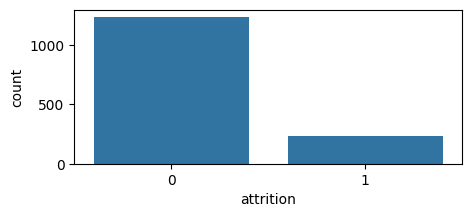

In [ ]:
# check data is balanced or not
plt.figure(figsize=(5,2))
sns.countplot(data,x='attrition')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
x_sampled,y_sampled = smote.fit_resample(x_train,y_train)


In [ ]:
Counter(y)

Counter({1: 237, 0: 1233})

In [ ]:
Counter(y_sampled)

Counter({0: 978, 1: 978})

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# slope
model.coef_

array([[-7.83338498e-02, -5.79531244e-02,  1.11655717e-01,
         5.92664357e-03,  0.00000000e+00, -3.31775667e-03,
        -1.27833979e-01, -3.44641902e-04, -1.33453446e-01,
        -1.91116799e-02, -1.79018973e-01, -1.11554692e-04,
         1.19745864e-05,  2.98054803e-01, -7.46633433e-02,
         2.44486605e-03, -3.11146440e-02,  2.00099143e-02,
        -2.02021930e-01, -5.40338228e-02, -1.19654158e-01,
        -6.67209960e-02,  1.60604477e-01, -2.24130545e-01,
         1.06315733e-01, -1.36286214e-01, -2.13812658e-02,
         2.16313898e-02,  7.59451363e-03, -3.13568032e-02,
         2.84367867e-02, -2.78447261e-02, -4.82209188e-03,
         2.82424448e-02,  4.74069855e-03, -7.69470226e-02,
         7.24564480e-02, -3.56431623e-02,  7.16487625e-02,
        -3.57554763e-02, -3.47413104e-02,  6.04491982e-03,
         2.51913095e-02, -9.15512488e-04, -2.91239586e-02,
        -8.89159727e-03, -2.87145833e-02,  2.59704309e-02,
         4.54304258e-02, -6.54507292e-02, -6.86125452e-0

In [ ]:
# intercept
model.intercept_

array([0.00024977])

In [ ]:
model.predict_proba(x_test)

array([[0.94613573, 0.05386427],
       [0.89863227, 0.10136773],
       [0.603788  , 0.396212  ],
       [0.95618174, 0.04381826],
       [0.8732364 , 0.1267636 ],
       [0.86510139, 0.13489861],
       [0.85583856, 0.14416144],
       [0.67409292, 0.32590708],
       [0.6866094 , 0.3133906 ],
       [0.9035474 , 0.0964526 ],
       [0.84454189, 0.15545811],
       [0.9431833 , 0.0568167 ],
       [0.3992755 , 0.6007245 ],
       [0.93084645, 0.06915355],
       [0.86845194, 0.13154806],
       [0.94900873, 0.05099127],
       [0.54144887, 0.45855113],
       [0.96892073, 0.03107927],
       [0.94328891, 0.05671109],
       [0.91827112, 0.08172888],
       [0.80101961, 0.19898039],
       [0.88394214, 0.11605786],
       [0.87689449, 0.12310551],
       [0.81196992, 0.18803008],
       [0.88004239, 0.11995761],
       [0.94891363, 0.05108637],
       [0.80187637, 0.19812363],
       [0.97754612, 0.02245388],
       [0.79682282, 0.20317718],
       [0.87705485, 0.12294515],
       [0.

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

# **KNN Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score , roc_auc_score

In [ ]:
confusion_matrix(y_test,y_pred)

array([[169,  86],
       [ 27,  12]])

In [ ]:
accuracy_score(y_test,y_pred)

0.6156462585034014

In [ ]:
precision_score(y_test,y_pred)

0.12244897959183673

In [ ]:
recall_score(y_test,y_pred)

0.3076923076923077

In [ ]:
f1_score(y_test,y_pred)

0.17518248175182483

# find k

In [ ]:
error =[]
for k in range(2,11):
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(x_sampled,y_sampled)
  y_pred=model.predict(x_test)
  error.append(np.mean(y_pred!=y_test))
print(error)

[np.float64(0.23809523809523808), np.float64(0.3469387755102041), np.float64(0.29931972789115646), np.float64(0.3843537414965986), np.float64(0.3401360544217687), np.float64(0.37755102040816324), np.float64(0.3401360544217687), np.float64(0.37755102040816324), np.float64(0.3435374149659864)]


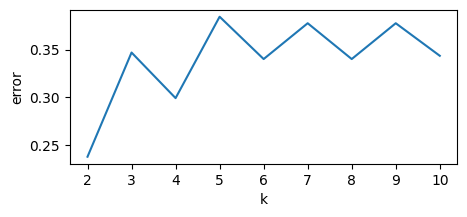

In [ ]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),error)
plt.xlabel('k')
plt.ylabel('error')
plt.show()

# Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[233  22]
 [ 30   9]]
Accuracy score:  0.8231292517006803
Precision score:  0.2903225806451613
Recall score:  0.23076923076923078
f1 score:  0.2571428571428571


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini',max_depth=50,
                               max_features='sqrt',splitter='best',
                               min_samples_leaf=5,min_samples_split=6)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[212  43]
 [ 26  13]]
Accuracy score:  0.7653061224489796
Precision score:  0.23214285714285715
Recall score:  0.3333333333333333
f1 score:  0.2736842105263158


## **Ramdom Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[250   5]
 [ 31   8]]
Accuracy score:  0.8775510204081632
Precision score:  0.6153846153846154
Recall score:  0.20512820512820512
f1 score:  0.3076923076923077


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=10,max_depth=10,criterion='gini',
                               max_features='sqrt',min_samples_split=6,
                               min_samples_leaf=5
                               ,bootstrap=True)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[235  20]
 [ 25  14]]
Accuracy score:  0.8469387755102041
Precision score:  0.4117647058823529
Recall score:  0.358974358974359
f1 score:  0.3835616438356164


# Evaluation of Classification
* Confusion Matrix
* Accuracy
* recall
* precision
* f1 score
* AUC-ROC curve

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8469387755102041

In [ ]:
# recall
recall_score(y_test,y_pred)

0.358974358974359

In [ ]:
# precision score
precision_score(y_test,y_pred)


0.4117647058823529

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.3835616438356164

In [ ]:
# # auc -roc
from sklearn.metrics import roc_curve , roc_auc_score

In [ ]:
y_prob = model.predict_proba(x_test)[:,1]
y_prob

array([0.27983974, 0.05666667, 0.55896465, 0.2089184 , 0.28255772,
       0.57125541, 0.55483405, 0.16401515, 0.50443723, 0.10852007,
       0.50029221, 0.43300866, 0.24833333, 0.3557548 , 0.23019481,
       0.35044678, 0.53519841, 0.52285076, 0.28260073, 0.11444444,
       0.3968254 , 0.29561966, 0.20666667, 0.14727273, 0.09857143,
       0.21166667, 0.50800866, 0.02466667, 0.29222222, 0.19788095,
       0.13620707, 0.15277778, 0.        , 0.2926378 , 0.55923993,
       0.10583333, 0.05      , 0.38660173, 0.68808781, 0.0961039 ,
       0.21734127, 0.26467989, 0.1295873 , 0.02740741, 0.74142857,
       0.13871573, 0.55823718, 0.60293684, 0.41221102, 0.6468254 ,
       0.19833333, 0.11634615, 0.12228571, 0.17899225, 0.23576144,
       0.39328283, 0.17512626, 0.05      , 0.23142857, 0.21190476,
       0.23136364, 0.70764291, 0.18585859, 0.15870239, 0.40564103,
       0.47227444, 0.18055556, 0.22035256, 0.08482143, 0.38053605,
       0.27089744, 0.37442351, 0.47863636, 0.21142857, 0.11493

In [ ]:
roc_auc_score(y_test,y_prob)

np.float64(0.7469079939668175)

In [ ]:
fpr,tpr,threshold = roc_curve(y_test,y_prob)

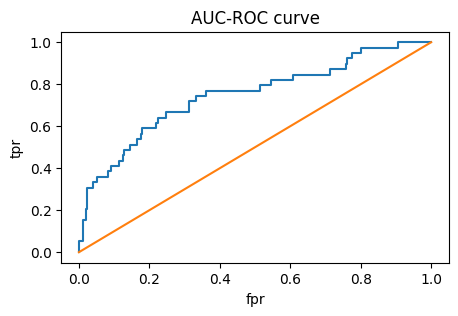

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('AUC-ROC curve')
plt.show()

## Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier()
model.fit(x_sampled, y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[244  11]
 [ 24  15]]
Accuracy score:  0.8809523809523809
Precision score:  0.5769230769230769
Recall score:  0.38461538461538464
f1 score:  0.46153846153846156


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(n_estimators=10,max_depth=10,
                                   max_features='sqrt',learning_rate=0.01,
                                   min_samples_split=5,min_samples_leaf=6)
model.fit(x_sampled , y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[239  16]
 [ 25  14]]
Accuracy score:  0.8605442176870748
Precision score:  0.4666666666666667
Recall score:  0.358974358974359
f1 score:  0.4057971014492754


# XGBOOST Classifier


In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[245  10]
 [ 28  11]]
Accuracy score:  0.8707482993197279
Precision score:  0.5238095238095238
Recall score:  0.28205128205128205
f1 score:  0.36666666666666664


In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=50,max_depth=10,
                      learning_rate=0.1, gamma=0.1,subsample=0.8,
                      colsample_bytree=0.8,reg_alpha =0.1 ,
                      reg_lambda=1,n_jobs=-1)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[246   9]
 [ 30   9]]
Accuracy score:  0.8673469387755102
Precision score:  0.5
Recall score:  0.23076923076923078
f1 score:  0.3157894736842105


# K Fold Cross validation

In [ ]:
from sklearn.model_selection import KFold,StratifiedKFold,cross_val_score
model = XGBClassifier()
kf = KFold(n_splits=5,shuffle =True,random_state=42)
scores = cross_val_score(model ,x_sampled,y_sampled,cv=kf)
print(scores)
print(np.mean(scores))

[0.91581633 0.90792839 0.91304348 0.9258312  0.9258312 ]
0.9176901195260712


# Stratified K fold Cross validation

In [ ]:
model = XGBClassifier()
sf = StratifiedKFold(n_splits=5,shuffle =True,random_state=42)
scores = cross_val_score(model ,x_sampled,y_sampled,cv=kf)
print(scores)
print(np.mean(scores))

[0.91581633 0.90792839 0.91304348 0.9258312  0.9258312 ]
0.9176901195260712


## Compare Model Performance

In [ ]:


result = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest','KNN'],
    'Accuracy':[acc_lr, acc_dt, acc_rf, acc_knn]
})

result

,Model,Accuracy
0,Logistic Regression,0.833333
1,Decision Tree,0.799320
2,Random Forest,0.860544
3,KNN,0.615646


## 20. Select Best Model

from the above graph we can find that **Random Forest Classifier** has best accuracy in the performance

## 21. Final Insights

Example:

- Employees with low job satisfaction leave more.
- Overtime increases attrition.
- Salary impacts retention.
- Work-life balance is important.